In [1]:
import pandas as pd
from pathlib import Path
import os 

ROOT_DIR = Path.cwd().parent
df_activity = pd.read_csv(os.path.join(ROOT_DIR, "data/processed/activity_data.csv"))
print( "Activity data: \n", df_activity.head() )

df_sleep = pd.read_csv(os.path.join(ROOT_DIR, "data/processed/sleep_data.csv"))
print("Sleep data: \n" ,df_sleep.head())

df_response = pd.read_csv(os.path.join(ROOT_DIR, "data/processed/t2d_long_format.csv"))
print("Response data: \n", df_response.head())
print("Response cols: \n", list(df_response.columns))

Activity data: 
          Date   Hour Day of Week  Day of Week Num   kcals   METs  ID  \
0  2023-03-22  00:00   mercoledì                3  32.213  1.212   5   
1  2023-03-22  01:00   mercoledì                3  30.330  1.257   5   
2  2023-03-22  02:00   mercoledì                3   7.457  1.060   5   
3  2023-03-22  03:00   mercoledì                3   2.053  1.000   5   
4  2023-03-22  04:00   mercoledì                3   1.142  1.000   5   

   Day_Since_First  
0                2  
1                2  
2                2  
3                2  
4                2  
Sleep data: 
   In_Bed_Date  Sleep_Efficiency  Total_Sleep_Time_TST  Number_of_Awakenings  \
0  2023-03-22             94.63                   458                    12   
1  2023-03-23             92.36                   423                     9   
2  2023-03-24             89.89                   489                    20   
3  2023-03-25             95.55                   408                     7   
4  2023-03-26  

/tmp/ipykernel_7183/3867865725.py:12: DtypeWarning: Columns (0: Snack pre/post) have mixed types. Specify dtype option on import or set low_memory=False.
  df_response = pd.read_csv(os.path.join(ROOT_DIR, "data/processed/t2d_long_format.csv"))


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

In [3]:
from glucose_model.data.preprocess import *

df_response = clean_response(df_response)
meals = build_meal_trajectories(df_response)

df_sleep_clean = clean_sleep(df_sleep)
df_activity_agg = aggregate_activity(df_activity)

meals = attach_context(meals, df_sleep_clean, df_activity_agg)

[0.0, 0.0, 0, 1, 0]
[0.0, 0.0, 0, 1, 0]
[0.0, 0.0, 0, 1, 0]
[0.0, 0.0, 0, 1, 0]
[0.0, 0.0, 0, 1, 0]
[0.0, 0.0, 0, 0, 0]
[0.0, 0.0, 0, 0, 0]
[86.73, 0.0, 1, 0, 0]
[0.0, 1.7323333333333333, 1, 0, 0]
[0.0, 1.7634166666666669, 1, 0, 0]


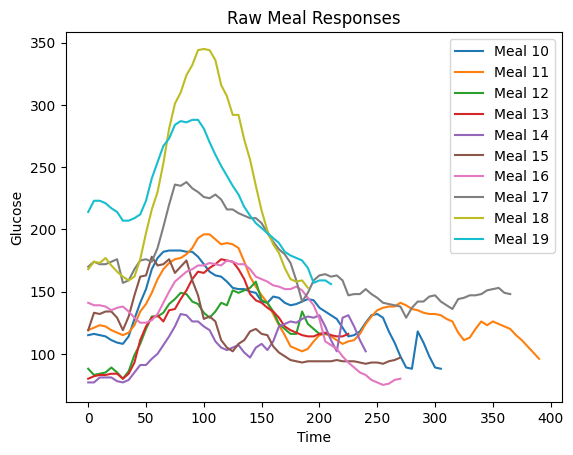

In [4]:
import matplotlib.pyplot as plt

for i in range(10,20):
    m = meals[i]
    plt.plot(m["time"], m["glucose"], label=f"Meal {i}")
    print(m["context"])
plt.legend()
plt.xlabel("Time")
plt.ylabel("Glucose")
plt.title("Raw Meal Responses")
plt.show()

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import skew

def extract_shape_features(time, glucose):
    time = np.array(time)
    glucose = np.array(glucose)

    baseline = glucose[0]
    peak = glucose.max()
    delta = peak - baseline

    peak_idx = np.argmax(glucose)
    time_to_peak = time[peak_idx]

    # slopes
    dt = np.diff(time)
    dg = np.diff(glucose)
    slopes = dg / dt
    max_slope = np.max(slopes)

    rise_slope = delta / time_to_peak if time_to_peak > 0 else 0

    # recovery
    below_baseline = np.where(glucose <= baseline)[0]
    time_to_baseline = (
        time[below_baseline[0]] if len(below_baseline) > 0 else np.nan
    )

    decay_slope = (
        (glucose[-1] - peak) / (time[-1] - time_to_peak)
        if time[-1] > time_to_peak else 0
    )

    # variability
    std = np.std(glucose)
    cv = std / np.mean(glucose)

    # shape
    skewness = skew(glucose)

    # auc
    auc = np.trapezoid(glucose, time)
    auc_i = np.trapezoid(glucose - baseline, time)

    return {
        "baseline": baseline,
        "peak": peak,
        "delta": delta,
        "time_to_peak": time_to_peak,
        "rise_slope": rise_slope,
        "max_slope": max_slope,
        "time_to_baseline": time_to_baseline,
        "decay_slope": decay_slope,
        "std": std,
        "cv": cv,
        "skewness": skewness,
        "auc": auc,
        "auc_i": auc_i,
    }

meal_type_map = {
    "breakfast": [1, 0, 0],
    "lunch": [0, 1, 0],
    "dinner": [0, 0, 1],
}


def meals_to_dataframe(meals):
    rows = []

    for m in meals:
        glucose = np.array(m["glucose"])
        time = np.array(m["time"])
        features = extract_shape_features(time, glucose)
        row = {
            "person_id": m["person_id"],

            # context
            "sleep_eff": m["context"][0],
            "activity": m["context"][1],
            "meal_type": m["context"][2],
            # meal
            "carbs": float(m["meal"]["carbs"]),
            "fat": float(m["meal"]["fat"]),
            "protein": float(m["meal"]["protein"]),

            # glucose features
            "peak": glucose.max(),
            "baseline": glucose[0],
            "delta": glucose.max() - glucose[0],
            **features
        }

        rows.append(row)

    return pd.DataFrame(rows)

In [6]:
df_meals = meals_to_dataframe(meals)
df_meals.head()

,person_id,sleep_eff,activity,meal_type,carbs,fat,protein,peak,baseline,delta,time_to_peak,rise_slope,max_slope,time_to_baseline,decay_slope,std,cv,skewness,auc,auc_i
0,1,0.0,0.0,1,69.8,15.3,25.7,228.0,145.0,83.0,80,1.037500,2.8,0,-0.500000,42.135215,0.313322,0.897583,47145.0,-3605.0
1,1,0.0,0.0,1,26.3,4.0,5.8,173.0,114.0,59.0,80,0.737500,2.2,0,-0.388571,22.797085,0.185574,0.903308,31392.5,2322.5
2,1,0.0,0.0,1,43.6,7.4,4.8,195.0,133.0,62.0,90,0.688889,4.2,0,-0.380000,33.477813,0.282830,0.821776,46220.0,-5650.0
3,1,0.0,0.0,1,26.3,4.0,5.8,206.0,132.0,74.0,85,0.870588,4.2,0,-0.409836,36.279846,0.324000,1.410354,43697.5,-7782.5
4,1,0.0,0.0,1,26.3,4.0,5.8,220.0,124.0,96.0,75,1.280000,4.2,0,-0.441270,42.853562,0.400690,1.300855,41732.5,-6627.5


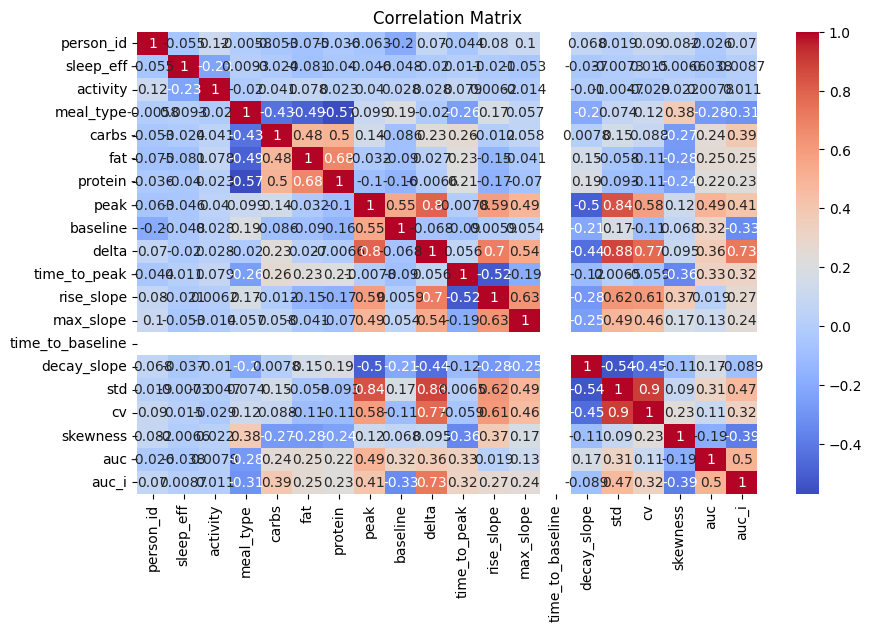

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
df_meals_clean = df_meals[(df_meals["sleep_eff"]>0) & (df_meals["activity"]>0)].copy()
plt.figure(figsize=(10, 6))
sns.heatmap(df_meals_clean.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

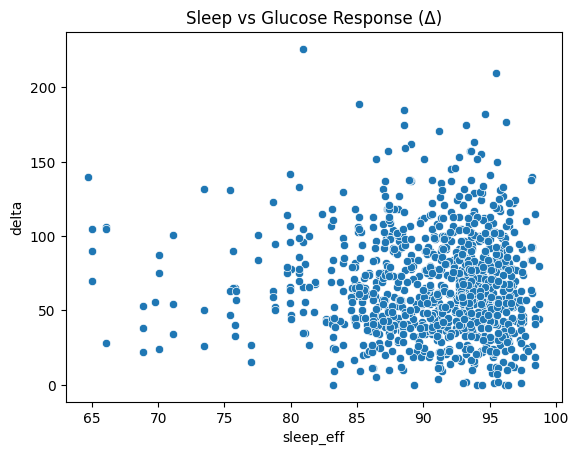

In [8]:

sns.scatterplot(data=df_meals_clean, x="sleep_eff", y="delta")
plt.title("Sleep vs Glucose Response (Δ)")
plt.show()

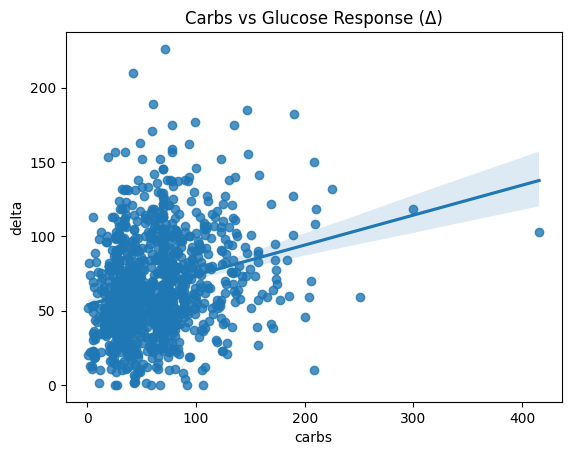

In [19]:
fig = plt.figure()
#sns.scatterplot(data=df_meals_clean, x="carbs", y="delta")
sns.regplot(data=df_meals_clean, x="carbs", y="delta")
plt.title("Carbs vs Glucose Response (Δ)")
plt.show()

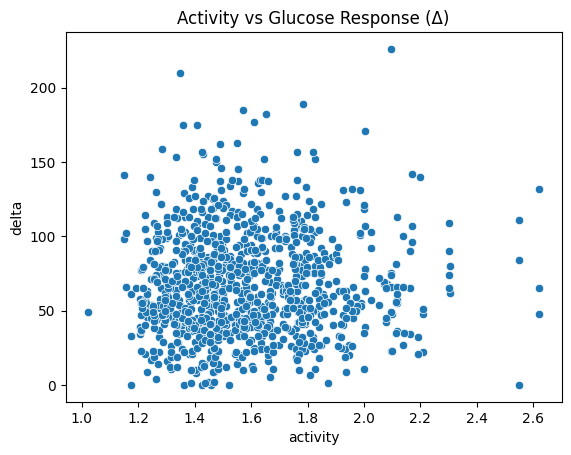

In [10]:
sns.scatterplot(data=df_meals_clean, x="activity", y="delta")
plt.title("Activity vs Glucose Response (Δ)")
plt.show()

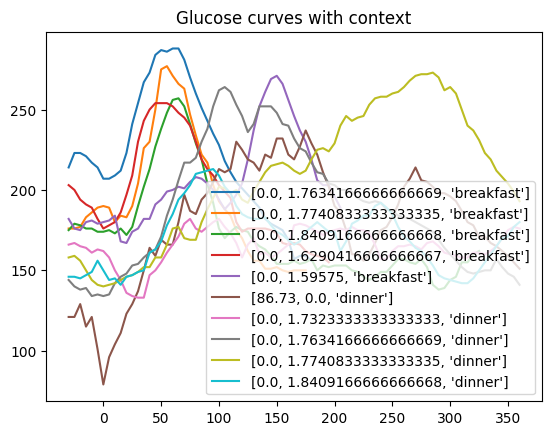

In [11]:
for i in range(20,30):
    m = meals[i]
    plt.plot(m["time"], m["glucose"], label=f"{m['context']}")

plt.legend()
plt.title("Glucose curves with context")
plt.show()


In [12]:
import statsmodels.api as sm

X = df_meals_clean[["carbs"]]
X = sm.add_constant(X)

y = df_meals_clean["delta"]

model = sm.OLS(y, X).fit()

df_meals_clean["residual"] = model.resid

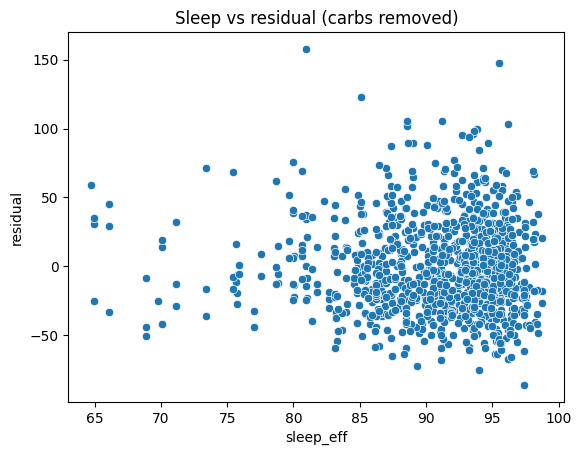

In [13]:
sns.scatterplot(data=df_meals_clean, x="sleep_eff", y="residual")
plt.title("Sleep vs residual (carbs removed)")
plt.show()

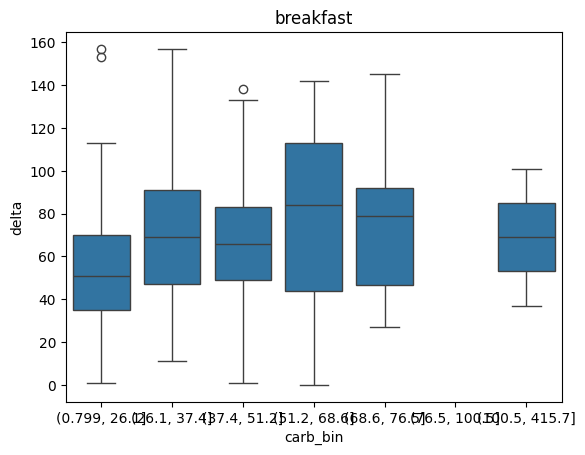

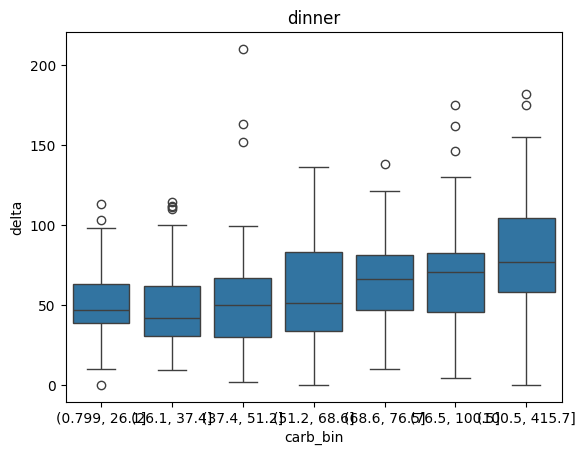

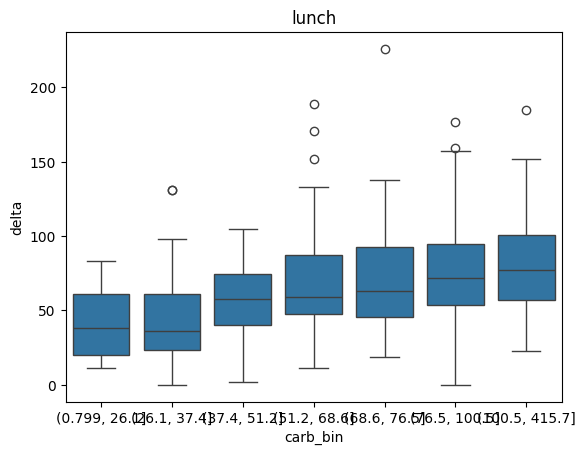

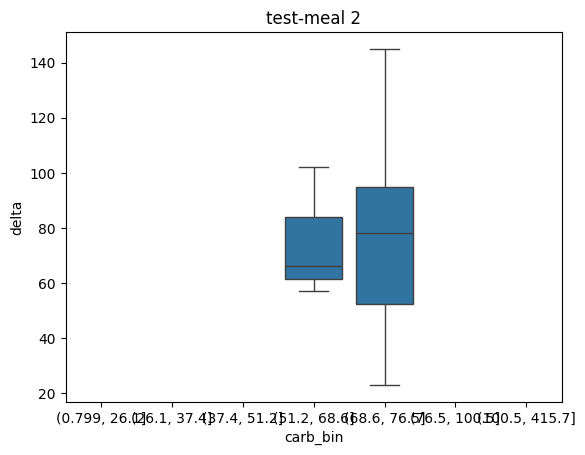

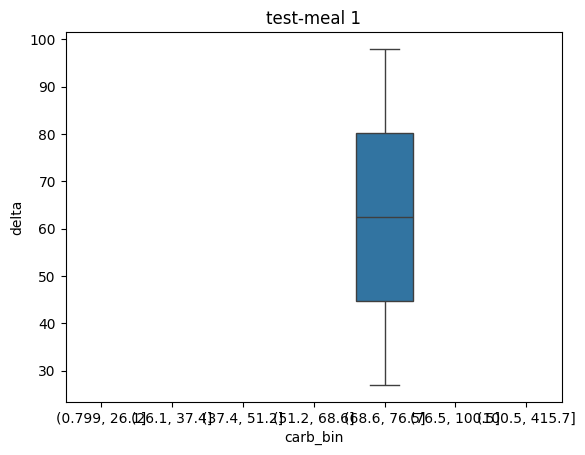

In [14]:
df_meals_clean["carb_bin"] = pd.qcut(df_meals_clean["carbs"], q=7)

for m_type in df_meals_clean["meal_type"].unique():
    sns.boxplot(data=df_meals_clean[df_meals_clean["meal_type"]==m_type], x="carb_bin", y="delta")
    plt.title(m_type)
    plt.show()

Text(0.5, 1.0, 'Carb distribution by meal type')

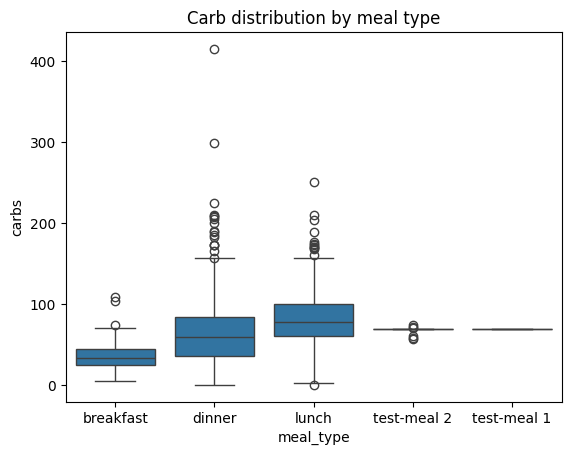

In [20]:
sns.boxplot(data=df_meals_clean, x="meal_type", y="carbs")
plt.title("Carb distribution by meal type")

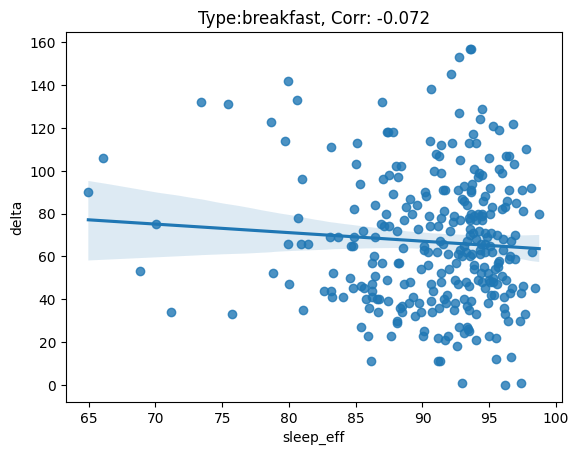

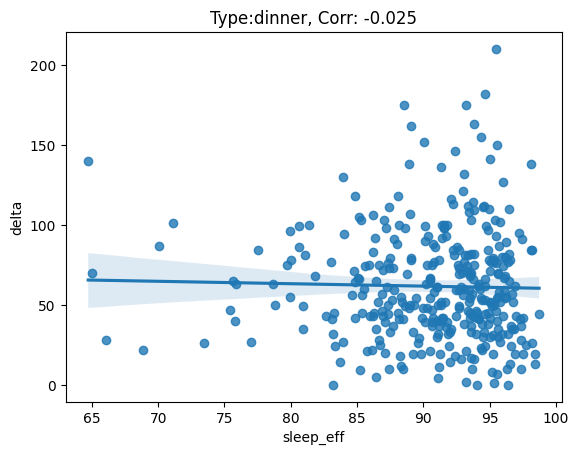

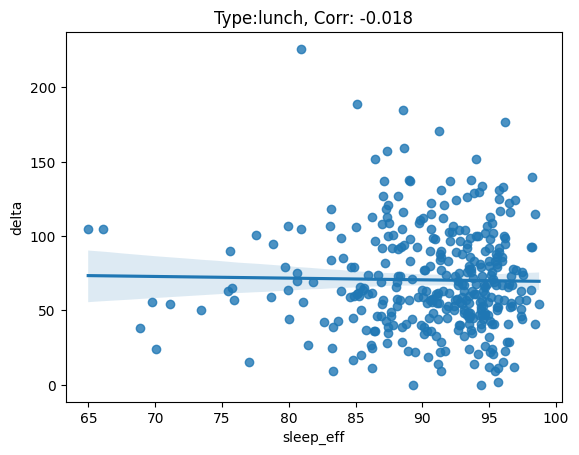

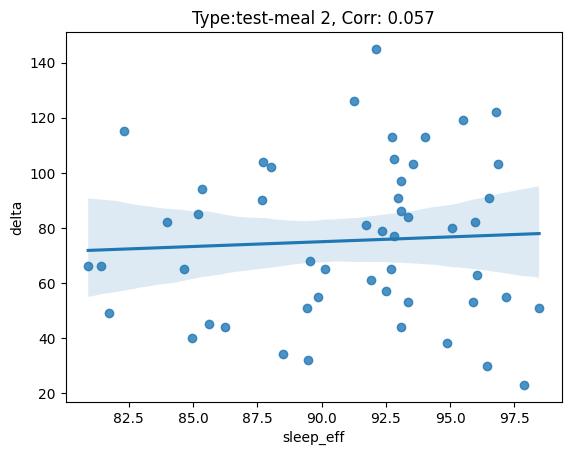

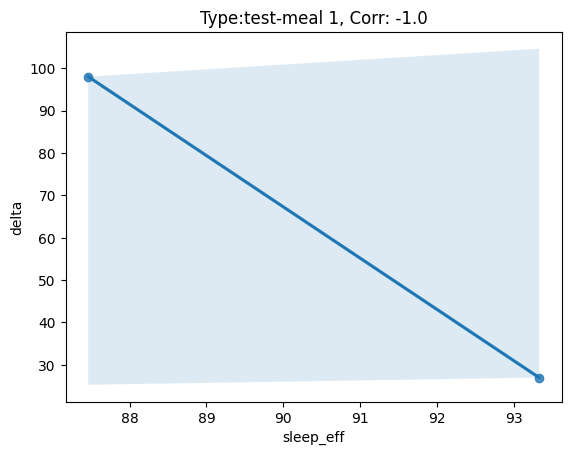

In [35]:
for m_type in df_meals_clean["meal_type"].unique():
    df_b = df_meals_clean[df_meals_clean["meal_type"] == m_type]
    sns.regplot(data=df_b, x="sleep_eff", y="delta")
    corr_coef = str( round( df_b["sleep_eff"].corr(df_b["delta"]), 3) )
    
    plt.title(f"Type:{m_type}, Corr: {corr_coef}")
    plt.show()

In [15]:
features= ["baseline",
        "peak",
        "delta",
        "time_to_peak",
        "rise_slope",
        "max_slope",
        "time_to_baseline",
        "decay_slope",
        "std",
        "cv",
        "skewness",
        "auc",
        "auc_i"]

for feature in features:
    print("Feature:", feature)
    for bin in df_meals_clean["carb_bin"].unique():
        df_bin = df_meals_clean[df_meals_clean["carb_bin"] == bin]

        # plt.figure()
        # sns.scatterplot(
        #     data=df_bin,
        #     x="sleep_eff",
        #     y="delta"
        # )
        # plt.title(f"Carb bin: {bin}")
        # plt.show()

        corr = df_bin["sleep_eff"].corr(df_bin[feature])
        print(f"{bin}: correlation = {corr:.3f}")

Feature: baseline
(68.6, 76.5]: correlation = -0.092
(37.4, 51.2]: correlation = 0.102
(0.799, 26.1]: correlation = 0.039
(26.1, 37.4]: correlation = -0.131
(51.2, 68.6]: correlation = -0.105
(76.5, 100.5]: correlation = 0.027
(100.5, 415.7]: correlation = -0.061
Feature: peak
(68.6, 76.5]: correlation = -0.133
(37.4, 51.2]: correlation = 0.058
(0.799, 26.1]: correlation = 0.109
(26.1, 37.4]: correlation = -0.121
(51.2, 68.6]: correlation = -0.150
(76.5, 100.5]: correlation = -0.002
(100.5, 415.7]: correlation = -0.079
Feature: delta
(68.6, 76.5]: correlation = -0.094
(37.4, 51.2]: correlation = -0.006
(0.799, 26.1]: correlation = 0.103
(26.1, 37.4]: correlation = -0.052
(51.2, 68.6]: correlation = -0.094
(76.5, 100.5]: correlation = -0.020
(100.5, 415.7]: correlation = -0.041
Feature: time_to_peak
(68.6, 76.5]: correlation = 0.144
(37.4, 51.2]: correlation = -0.084
(0.799, 26.1]: correlation = -0.096
(26.1, 37.4]: correlation = 0.001
(51.2, 68.6]: correlation = 0.035
(76.5, 100.5]: co

/home/vikska/projects/dynamic-metabolic-state/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vikska/projects/dynamic-metabolic-state/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


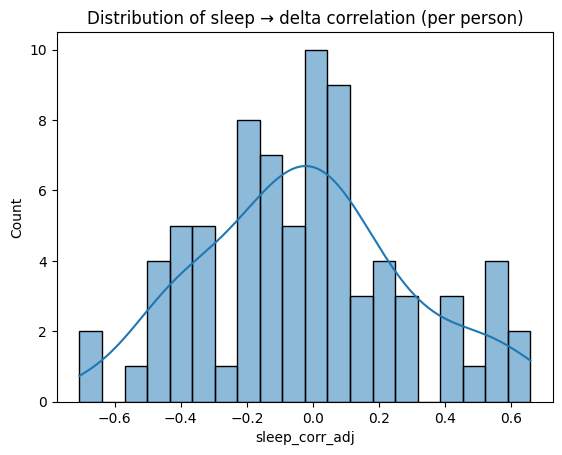

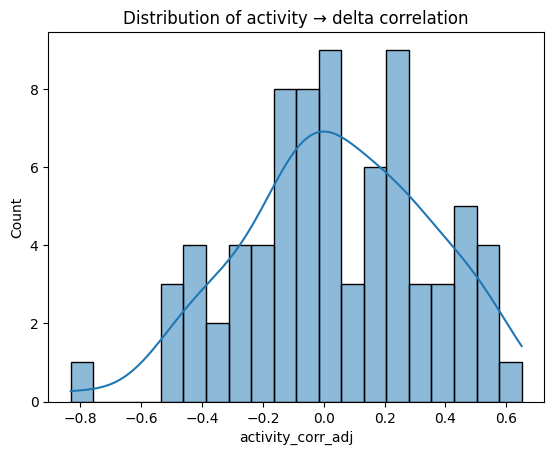

In [16]:
import statsmodels.api as sm

results = []

for person_id, df_p in df_meals_clean.groupby("person_id"):
    if len(df_p) < 5:
        continue

    # --- control for carbs ---
    X = sm.add_constant(df_p["carbs"])
    y = df_p["delta"]

    model = sm.OLS(y, X).fit()
    residuals = model.resid

    # --- now correlate sleep with residuals ---
    corr_sleep = df_p["sleep_eff"].corr(residuals)
    corr_activity = df_p["activity"].corr(residuals)

    results.append({
        "person_id": person_id,
        "n_meals": len(df_p),
        "sleep_corr_adj": corr_sleep,
        "activity_corr_adj": corr_activity
    })

df_person = pd.DataFrame(results)

sns.histplot(df_person["sleep_corr_adj"], bins=20, kde=True)
plt.title("Distribution of sleep → delta correlation (per person)")
plt.show()
sns.histplot(df_person["activity_corr_adj"], bins=20, kde=True)
plt.title("Distribution of activity → delta correlation")
plt.show()

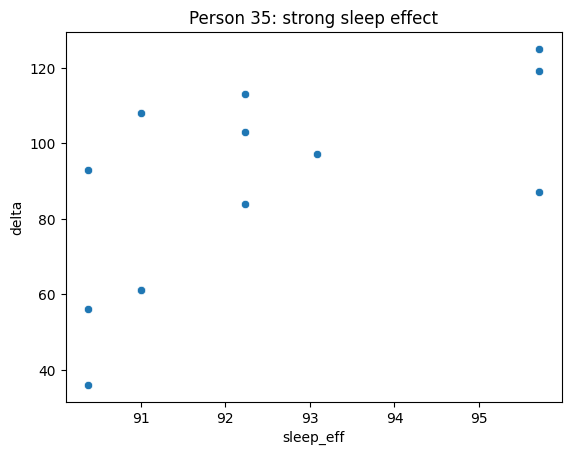

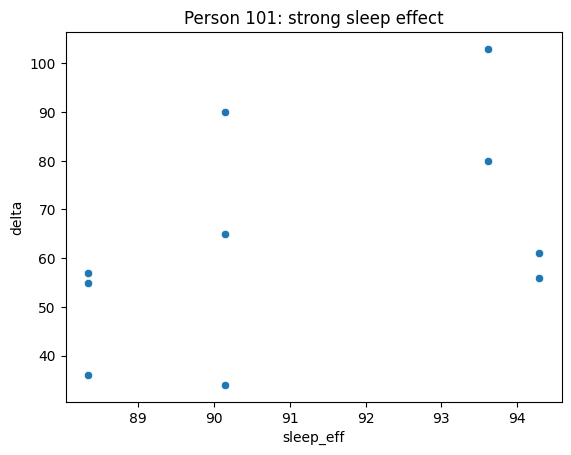

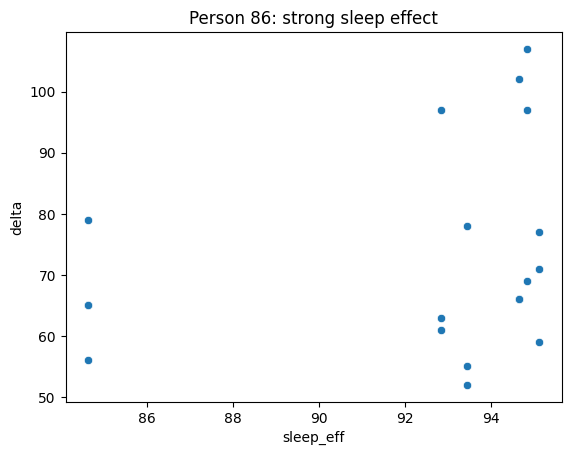

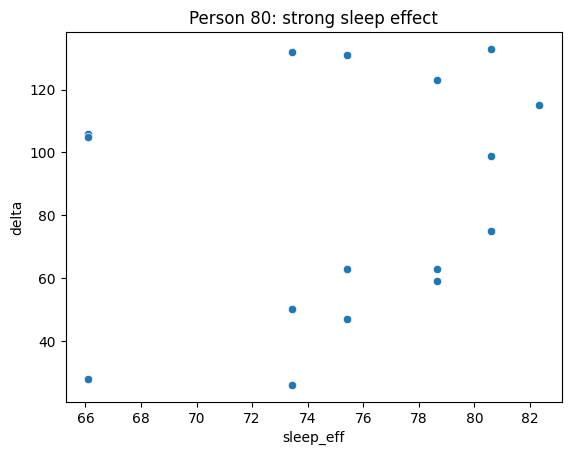

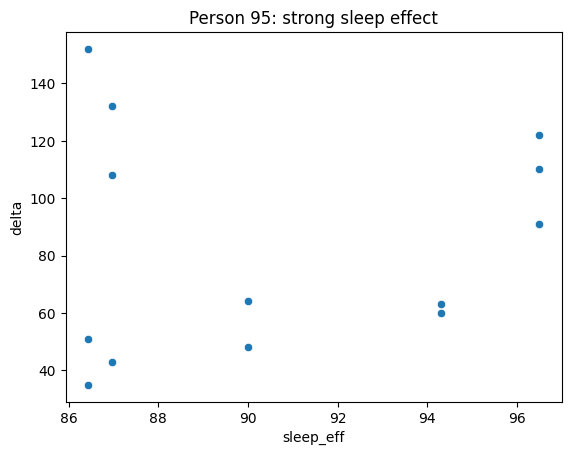

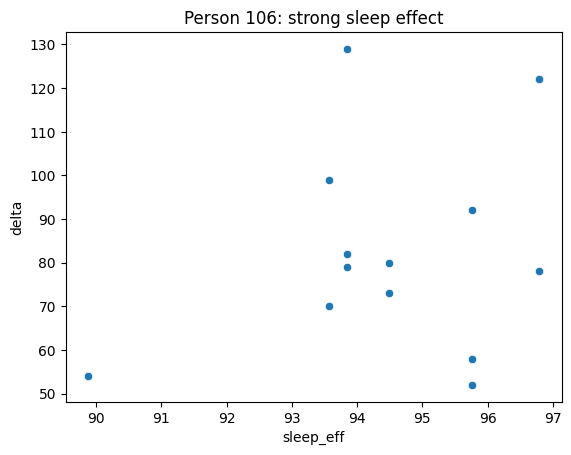

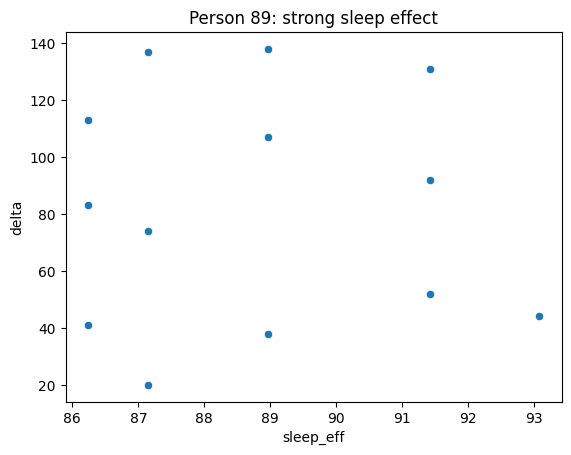

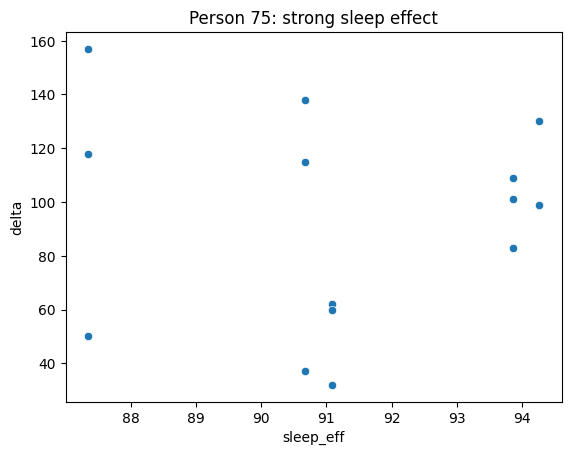

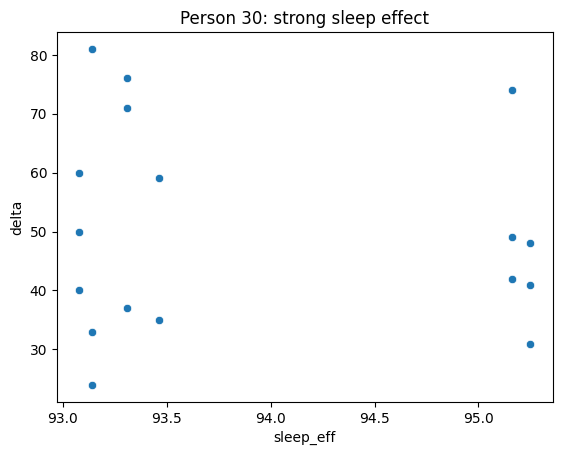

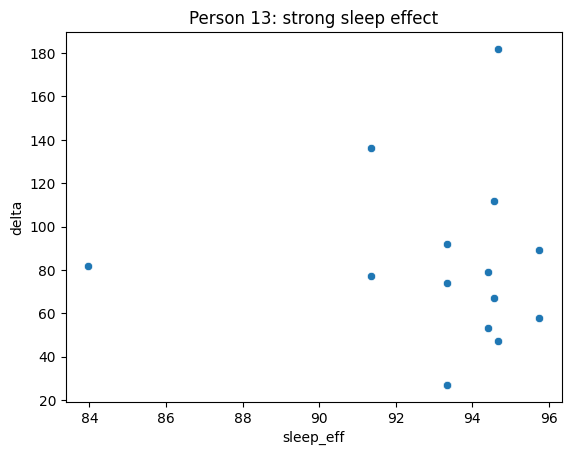

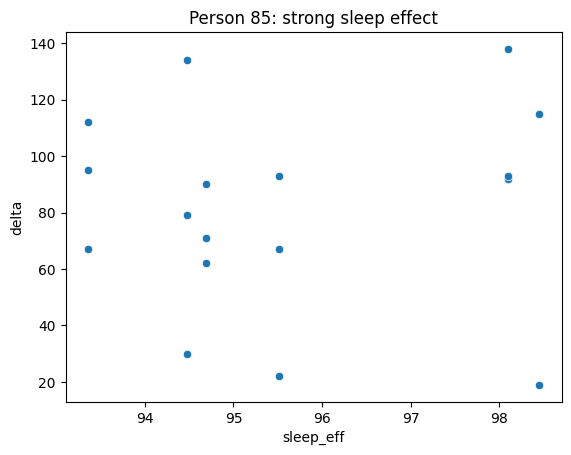

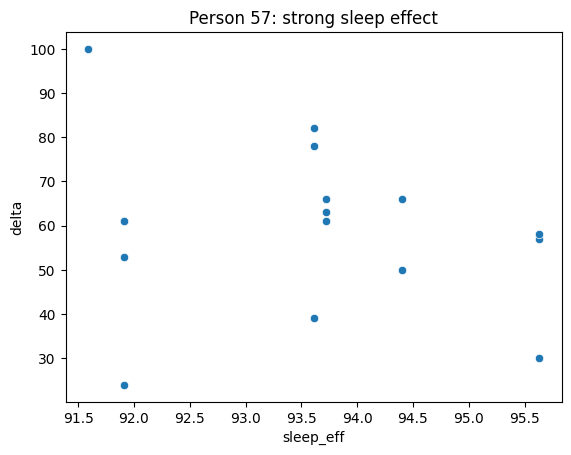

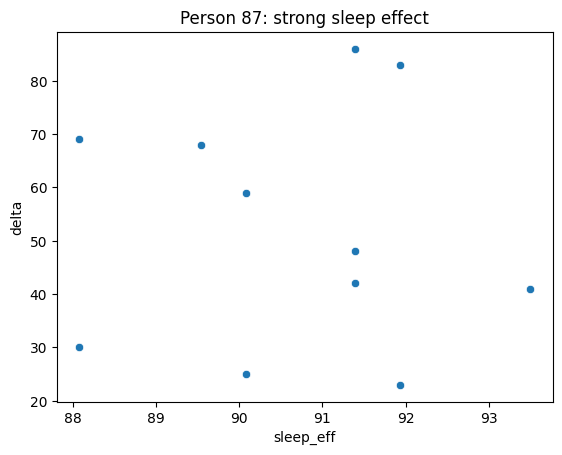

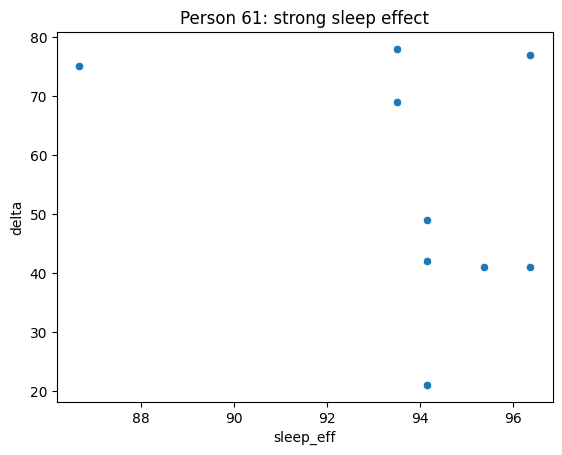

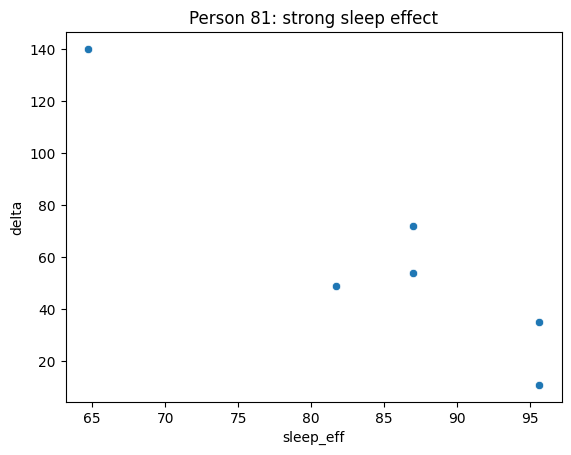

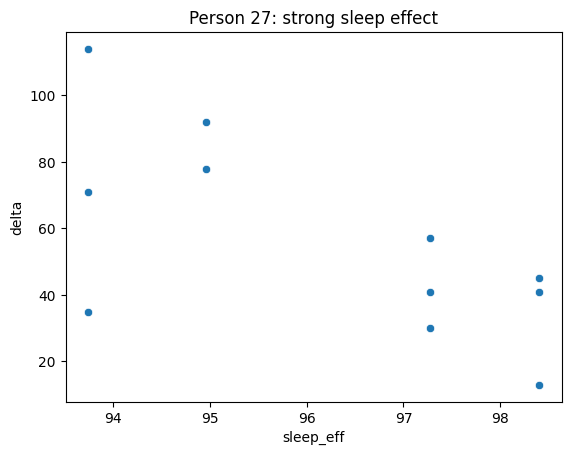

In [17]:
df_person.sort_values("sleep_corr_adj").head(10)   # strong negative
df_person.sort_values("sleep_corr_adj").tail(10)   # strong positive


for person_id in df_person.sort_values("sleep_corr_adj").iloc[::-5]["person_id"]:

    df_p = df_meals_clean[df_meals_clean["person_id"] == person_id]

    sns.scatterplot(data=df_p, x="sleep_eff", y="delta")
    plt.title(f"Person {person_id}: strong sleep effect")
    plt.show()